# Stage 0 — Study 4: Failure Analysis

**Goal.** "Success" and "failure" are both underspecified in this setting: the attack can fail
outright (Phase 1 never crosses the boundary), succeed on paper but make no useful progress
(Phase 3 returns an adversarial example that's barely closer to the original than Phase 2 left
it), or succeed well (the boundary point moves substantially toward the original image). These
three regimes have different causes and call for different fixes — conflating them in a single
binary success rate hides more than it reveals.

This study runs **100 images, 10 per class** (stratified) against **both models** (standard and
robust WRN-28-10) with **two init methods** (uniform random — the paper's Algorithm 1 baseline
— and fractal — Algorithm 3 / "EvolBA+I") and asks:

* **A. Failure taxonomy and rates.** How often does each failure mode occur, and does it
  depend on the model or initialisation method?
* **B. Source-class distribution.** Are certain true-label classes systematically hard to
  attack? Is the hard-class set the same for both models?
* **C. Attractor-class mechanism.** When Phase 1 finds an adversarial example, which class
  does it land in? Does that specific target class predict whether Phase 3 will succeed?
* **D. Does fractal init escape attractor failures?** Compare uniform- vs fractal-init class
  distributions and failure rates directly.
* **E. Geometric predictor.** Does the Phase-2 boundary distance (`init_l2`) predict Phase-3
  improvement? If yes, failure is a Phase-1/2 problem; if no, it is a Phase-3 problem.
* **F. Cross-model correlation.** Are the same images hard for both models, or do they swap?
* **G. ξ-shrink as an early warning.** Can the number of ξ halvings in the first few
  generations predict whether the run will eventually succeed or stagnate?

---

**Failure taxonomy — four buckets used throughout this study:**

| bucket | condition | threshold |
|--------|-----------|-----------|
| **hard** | Phase 1 never crossed the decision boundary | `success = False` |
| **flat** | Phase 3 made negligible progress | IR < 0.05 |
| **partial** | Phase 3 improved but not enough | 0.05 ≤ IR < 0.50 |
| **good** | Phase 3 halved the L2 distance or better | IR ≥ 0.50 |

where **IR** (improvement ratio) = (init\_l2 − final\_l2) / init\_l2, and **init\_l2** is the L2
distance between x\_orig and the Phase-2 boundary point.

---
**Study 1 connection.** Study 1's bimodal generation-count finding (3–12 vs 41–44 gens, N=8)
and the attractor-class note (1/8 runs showed suspicious init-class patterns) motivated this
study. N=100 with class stratification should resolve both.

In [1]:
import os, sys, time, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from robustbench.utils import load_model as rb_load_model

warnings.filterwarnings('ignore')

_root = Path.cwd()
if not (_root / 'evolba_baseline.py').exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

import config
from evolba_baseline import (
    objective, binary_search,
    generate_fractal_image, blend_frequencies,
    sep_cmaes_weights, mean_shift_direction, update_diagonal_covariance,
    TAU, INIT_CUTOFF, JUMP_EVERY,
)

# ── study-level constants ─────────────────────────────────────────────────────
SEED             = config.SEED
N_PER_CLASS      = 10          # 10 images × 10 classes = 100 total
N_CLASSES        = 10
MAX_Q            = config.MAX_Q_CIFAR10   # 3000 per attack
OUTPUT_DIR       = './outputs/study4_failure'
RUNS_FILE        = f'{OUTPUT_DIR}/runs.parquet'
GENS_FILE        = f'{OUTPUT_DIR}/gens.parquet'
CIFAR10_MEAN     = config.CIFAR10_MEAN
CIFAR10_STD      = config.CIFAR10_STD
CIFAR10_CLASSES  = config.CIFAR10_CLASSES

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

/home/tomma/EvolBA/EV_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
# ── load both models ─────────────────────────────────────────────────────────
print('Loading Standard WRN-28-10...')
std_model = rb_load_model(model_name='Standard', dataset='cifar10',
                          threat_model='Linf').to(device).eval()
print('Loading Robust WRN-28-10 (Wang2023Better / TRADES)...')
rob_model = rb_load_model(model_name='Wang2023Better_WRN-28-10', dataset='cifar10',
                          threat_model='Linf').to(device).eval()

# Both RobustBench models (Standard and Wang2023Better) apply their own
# normalisation internally — passing a pre-normalised tensor would double-apply
# it and destroy per-class accuracy for some classes.  Use identity for both.
def norm_std(x): return x   # Standard normalises internally
def norm_rob(x): return x   # Wang2023Better normalises internally

MODELS = {'standard': (std_model, norm_std), 'robust': (rob_model, norm_rob)}

@torch.no_grad()
def predict_batch(model, norm_fn, x_chw_batch: np.ndarray) -> np.ndarray:
    """Score a (B, C, H, W) float32 [0,1] array, return class indices."""
    xb = torch.from_numpy(x_chw_batch).float().to(device)
    return model(norm_fn(xb)).argmax(1).cpu().numpy()

# ── single-image oracle and batched-image oracle for each model ───────────────
def make_oracles(model, norm_fn):
    def oracle_fn(img):
        """Single CHW float32 image -> Top-1 label."""
        t = torch.from_numpy(img).float().unsqueeze(0).to(device)
        with torch.no_grad():
            return int(model(norm_fn(t)).argmax(1).item())
    def batched_oracle_fn(imgs):
        """(B, C, H, W) float32 array -> (B,) label array."""
        return predict_batch(model, norm_fn, imgs)
    return oracle_fn, batched_oracle_fn

ORACLES = {name: make_oracles(*pair) for name, pair in MODELS.items()}
print('Models ready.')

Loading Standard WRN-28-10...


Loading Robust WRN-28-10 (Wang2023Better / TRADES)...


Models ready.


In [3]:
# ── collect 100 class-stratified images ──────────────────────────────────────
# Requirement: image is correctly classified by BOTH models (otherwise an
# "attack" could succeed before it even runs, biasing every metric).
# Strategy: walk the test set in order; keep the first N_PER_CLASS images per
# class that pass the double-correct filter.

test_dataset = torchvision.datasets.CIFAR10(
    root='../data', train=False, download=True, transform=T.ToTensor(),
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=256, shuffle=False, num_workers=0
)

per_class = {c: [] for c in range(N_CLASSES)}   # class -> list of CHW float32 arrays

for imgs, labels_b in test_loader:
    x_np = imgs.numpy()                          # (B, C, H, W) float32
    p_std = predict_batch(*MODELS['standard'], x_np)
    p_rob = predict_batch(*MODELS['robust'],   x_np)
    both_correct = (p_std == labels_b.numpy()) & (p_rob == labels_b.numpy())
    for i in np.where(both_correct)[0]:
        lbl = int(labels_b[i])
        if len(per_class[lbl]) < N_PER_CLASS:
            per_class[lbl].append(x_np[i])
    if all(len(v) >= N_PER_CLASS for v in per_class.values()):
        break

# Flatten into (100,) arrays sorted by class, then shuffle
attack_images  = np.concatenate([np.stack(per_class[c]) for c in range(N_CLASSES)])
attack_labels  = np.array([c for c in range(N_CLASSES) for _ in range(N_PER_CLASS)], dtype=np.int64)

rng_shuffle = np.random.default_rng(SEED)
shuf = rng_shuffle.permutation(len(attack_images))
attack_images, attack_labels = attack_images[shuf], attack_labels[shuf]

print(f'Collected {len(attack_images)} images — class distribution:')
for c in range(N_CLASSES):
    print(f'  {CIFAR10_CLASSES[c]:>12s}: {(attack_labels == c).sum()}')

Collected 100 images — class distribution:
      airplane: 10
    automobile: 10
          bird: 10
           cat: 10
          deer: 10
           dog: 10
          frog: 10
         horse: 10
          ship: 10
         truck: 10


## Instrumented runner for failure analysis

`evolba_failure_instrumented` is Study 1's `evolba_instrumented` with two additions:

1. **`init_class`** — the adversarial class Phase 1 first lands in.  Captured by inlining Phase 1
   (instead of delegating to `uniform_random_init` / `fractal_init`) so the oracle's return
   label is readable without an extra query.
2. **`init_l2`** — `‖x̃⁽⁰⁾ − x_orig‖₂` immediately after Phase 2.  This is the distance the
   search *starts* Phase 3 from; comparing it to `best_l2` gives the improvement ratio.

Every other detail (gen_records structure, batched offspring scoring, backtracking, jump) is
byte-for-byte the Study-1 version.  The jump operator is disabled here (`use_jump=False`) so
the failure patterns we see belong to the core algorithm, not the jump rescue.

In [4]:
def evolba_failure_instrumented(
    oracle_fn, batched_oracle_fn, x_orig: np.ndarray, y_true: int,
    max_queries: int = MAX_Q, *,
    use_fractal_init: bool = False,
    x_fractal: np.ndarray | None = None,
    mean_shift_fn=mean_shift_direction, cmu_scale: float = 1.0,
    seed: int = SEED,
) -> dict:
    rng         = np.random.default_rng(seed)
    shape       = x_orig.shape
    n           = x_orig.size
    x_orig_flat = x_orig.flatten().astype(np.float64)

    queries = [0]
    def query(img):
        queries[0] += 1
        return oracle_fn(img)
    def query_batch(imgs):
        queries[0] += len(imgs)
        return batched_oracle_fn(imgs)

    if x_fractal is None and use_fractal_init:
        x_fractal = generate_fractal_image(shape, seed)

    # ── Phase 1: find initial adversarial — inlined to capture init_class ─────
    q0 = queries[0]
    init_class, x0 = None, None

    if use_fractal_init:
        for r in range(INIT_CUTOFF, -1, -1):
            x_cand = blend_frequencies(x_orig, x_fractal, r)
            lbl = query(x_cand)
            if lbl != y_true:
                x0, init_class = x_cand, lbl; break
        if x0 is None:           # fractal never crossed — fall back to uniform noise
            for _ in range(1000):
                x = rng.uniform(0.0, 1.0, size=shape).astype(np.float32)
                lbl = query(x)
                if lbl != y_true:
                    x0, init_class = x, lbl; break
    else:
        for _ in range(1000):
            x = rng.uniform(0.0, 1.0, size=shape).astype(np.float32)
            lbl = query(x)
            if lbl != y_true:
                x0, init_class = x, lbl; break

    q_init_search = queries[0] - q0
    if x0 is None:
        return {'success': False, 'queries': queries[0],
                'init_class': None, 'init_l2': None}

    # ── Phase 2: binary search to the boundary ────────────────────────────────
    q0 = queries[0]
    x_tilde0       = binary_search(query, x0, x_orig, y_true)
    q_init_project = queries[0] - q0
    init_queries   = queries[0]
    init_l2        = float(np.linalg.norm(x_tilde0.flatten() - x_orig_flat))

    # ── Sep-CMA-ES initialisation ─────────────────────────────────────────────
    m           = x_tilde0.flatten().astype(np.float64)
    D           = np.ones(n, dtype=np.float64)
    lam         = 4 + int(3 * np.log(n))
    mu          = lam
    weights, mueff = sep_cmaes_weights(mu)
    c1  = 2.0 / ((n + 1.3) ** 2 + mueff)
    cmu = min(1.0 - c1, 2.0 * (mueff - 2.0 + 1.0 / mueff) / ((n + 2.0) ** 2 + mueff))
    cmu = cmu * (n + 2.0) / 3.0 * cmu_scale

    gen_l2_history, gen_records, gen_images = [], [], []
    t = 1

    # ── Algorithm 1 main loop ─────────────────────────────────────────────────
    while queries[0] < max_queries:
        dist_to_orig = float(np.linalg.norm(m - x_orig_flat))
        xi           = dist_to_orig / np.sqrt(t)

        # Offspring (batched forward pass)
        q0      = queries[0]
        zs      = rng.standard_normal((lam, n))
        xs      = np.clip(m + xi * D * zs, 0.0, 1.0)
        labels  = query_batch(xs.reshape((lam,) + shape).astype(np.float32))
        l2s     = np.linalg.norm(xs - x_orig_flat, axis=1)
        is_adv  = labels != y_true
        fitness = np.array([objective(l2, adv) for l2, adv in zip(l2s, is_adv)])
        q_offspring = queries[0] - q0

        v = mean_shift_fn(zs, fitness, is_adv, weights)
        D = update_diagonal_covariance(D, zs, fitness, weights, cmu)

        # ξ-shrink
        q0        = queries[0]
        m_shifted = np.clip(m + xi * v, 0.0, 1.0)
        n_shrinks = 0
        while query(m_shifted.reshape(shape).astype(np.float32)) == y_true:
            xi /= 2.0; n_shrinks += 1
            m_shifted = np.clip(m + xi * v, 0.0, 1.0)
            if queries[0] >= max_queries: break
        q_xi_shrink = queries[0] - q0

        # Boundary pull
        q0    = queries[0]
        m_new = binary_search(query, m_shifted.reshape(shape).astype(np.float32), x_orig, y_true)
        m_new = m_new.flatten().astype(np.float64)
        q_boundary_pull = queries[0] - q0

        # Backtracking
        q0         = queries[0]
        backtracks = 0
        while (np.linalg.norm(m_new - x_orig_flat) > dist_to_orig
               and backtracks < TAU and queries[0] < max_queries):
            xi   /= 2.0
            cand  = np.clip(m + xi * v, 0.0, 1.0).reshape(shape).astype(np.float32)
            m_new = binary_search(query, cand, x_orig, y_true).flatten().astype(np.float64)
            backtracks += 1
        q_backtrack = queries[0] - q0

        m        = m_new
        l2_after = float(np.linalg.norm(m - x_orig_flat))
        gen_l2_history.append(l2_after)
        gen_images.append(m.reshape(shape).astype(np.float32))
        gen_records.append(dict(
            gen=t, cum_queries=queries[0],
            l2_before=dist_to_orig, l2_after=l2_after,
            xi_initial=dist_to_orig / np.sqrt(t),
            n_xi_shrinks=n_shrinks, n_backtracks=backtracks,
            q_offspring=q_offspring, q_xi_shrink=q_xi_shrink,
            q_boundary_pull=q_boundary_pull, q_backtrack=q_backtrack,
            frac_adv_offspring=float(is_adv.mean()),
        ))
        t += 1

    best_l2 = float(np.linalg.norm(m - x_orig_flat))
    return {
        'success'       : True,
        'queries'       : queries[0],
        'best_l2'       : best_l2,
        'init_class'    : init_class,
        'init_l2'       : init_l2,
        'gen_l2_history': gen_l2_history,
        'gen_records'   : gen_records,
        'gen_images'    : gen_images,
        'q_init_search' : q_init_search,
        'q_init_project': q_init_project,
        'init_queries'  : init_queries,
    }

print('evolba_failure_instrumented ready')

evolba_failure_instrumented ready


## Run experiments

Four conditions: **2 models × 2 init methods = 400 attacks**, each up to `MAX_Q = 3000`
queries.  Results are written to `outputs/study4_failure/` immediately and the cell is
skipped on subsequent runs (load from disk instead of re-running).

| condition | model    | init          | key in results |
|-----------|----------|---------------|----------------|
| std_uni   | standard | uniform noise | `use_fractal_init=False` |
| std_frac  | standard | fractal blend | `use_fractal_init=True`  |
| rob_uni   | robust   | uniform noise | `use_fractal_init=False` |
| rob_frac  | robust   | fractal blend | `use_fractal_init=True`  |

In [5]:
if Path(RUNS_FILE).exists() and Path(GENS_FILE).exists():
    print('Results already on disk — skipping run.  Delete the parquet files to re-run.')
else:
    CONDITIONS = [
        ('standard', False),
        ('standard', True),
        ('robust',   False),
        ('robust',   True),
    ]
    COND_LABEL = {(m, fi): f'{m}_{"frac" if fi else "uni"}'
                  for m, fi in CONDITIONS}

    run_rows, gen_rows = [], []
    t0 = time.time()
    total = len(CONDITIONS) * len(attack_images)
    done  = 0

    for model_name, use_fi in CONDITIONS:
        oracle_fn, batched_oracle_fn = ORACLES[model_name]
        cond = COND_LABEL[(model_name, use_fi)]

        for idx in range(len(attack_images)):
            x_orig = attack_images[idx]
            y_true = int(attack_labels[idx])
            out    = evolba_failure_instrumented(
                oracle_fn, batched_oracle_fn, x_orig, y_true,
                max_queries=MAX_Q, use_fractal_init=use_fi, seed=SEED,
            )
            done += 1

            improvement_ratio = (
                (out['init_l2'] - out['best_l2']) / out['init_l2']
                if out.get('success') and out['init_l2'] and out['init_l2'] > 0
                else float('nan')
            )
            n_gens = len(out.get('gen_records', []))

            run_rows.append(dict(
                image_idx         = idx,
                true_class        = y_true,
                model             = model_name,
                init_method       = 'fractal' if use_fi else 'uniform',
                condition         = cond,
                success           = out['success'],
                init_class        = out.get('init_class'),
                init_l2           = out.get('init_l2'),
                final_l2          = out.get('best_l2'),
                improvement_ratio = improvement_ratio,
                total_queries     = out['queries'],
                n_generations     = n_gens,
            ))

            for gr in out.get('gen_records', []):
                gen_rows.append(dict(
                    image_idx   = idx,
                    true_class  = y_true,
                    model       = model_name,
                    init_method = 'fractal' if use_fi else 'uniform',
                    condition   = cond,
                    **gr,
                ))

            if done % 20 == 0 or not out['success']:
                tag = f"{CIFAR10_CLASSES[y_true]:>12s}"
                if out['success']:
                    print(f'[{cond:>12s}] {done:3d}/{total} {tag}'
                          f'  gens={n_gens:3d}  IR={improvement_ratio:.2f}'
                          f'  init_cls={CIFAR10_CLASSES[out["init_class"]] if out["init_class"] is not None else "?"}'
                    )
                else:
                    print(f'[{cond:>12s}] {done:3d}/{total} {tag}  INIT FAILED')

    runs_df = pd.DataFrame(run_rows)
    gens_df = pd.DataFrame(gen_rows)
    runs_df.to_parquet(RUNS_FILE)
    gens_df.to_parquet(GENS_FILE)
    print(f'\nDone in {time.time()-t0:.0f}s — {len(runs_df)} runs, '
          f'{runs_df.success.sum()} succeeded, '
          f'{(~runs_df.success).sum()} hard-failed')

[standard_uni]  20/400        truck  gens= 12  IR=0.49  init_cls=cat


[standard_uni]  40/400          cat  gens= 41  IR=0.61  init_cls=bird


[standard_uni]  60/400        truck  gens=  9  IR=0.11  init_cls=cat


[standard_uni]  80/400          dog  gens=  5  IR=0.01  init_cls=cat


[standard_uni] 100/400     airplane  gens= 39  IR=0.46  init_cls=cat


...

[ robust_frac] 323/400         bird  INIT FAILED


[ robust_frac] 340/400          cat  gens= 13  IR=0.03  init_cls=truck


[ robust_frac] 360/400        truck  gens=  2  IR=-0.00  init_cls=bird


[ robust_frac] 380/400          dog  gens=  5  IR=0.01  init_cls=cat


[ robust_frac] 400/400     airplane  gens=  8  IR=0.03  init_cls=cat

Done in 4128s — 400 runs, 387 succeeded, 13 hard-failed


In [6]:
# ── load results + classify failures ─────────────────────────────────────────
runs_df = pd.read_parquet(RUNS_FILE)
gens_df = pd.read_parquet(GENS_FILE)

# Failure taxonomy — four buckets, each with a concrete operational definition.
# Thresholds are deliberately generous: IR < 5% is "flat" even though a tiny
# improvement technically happened.  50% reduction is needed for "good".
#
#   hard    : Phase 1 never found an adversarial example          (success=False)
#   flat    : Phase 3 improved L2 by less than 5%                 (IR < 0.05)
#   partial : meaningful improvement but less than half           (0.05 <= IR < 0.50)
#   good    : Phase 3 cut L2 by at least half                     (IR >= 0.50)

def classify_failure(row):
    if not row['success']:
        return 'hard'
    ir = row['improvement_ratio']
    if np.isnan(ir) or ir < 0.05:
        return 'flat'
    elif ir < 0.50:
        return 'partial'
    return 'good'

runs_df['failure_type'] = runs_df.apply(classify_failure, axis=1)

# Add per-gen derived columns to gens_df
gens_df['total_xi_halvings'] = gens_df['n_xi_shrinks'] + gens_df['n_backtracks'] * 26

# Merge failure_type and improvement_ratio into gens_df for grouped analysis
gens_df = gens_df.merge(
    runs_df[['image_idx', 'model', 'init_method', 'failure_type', 'improvement_ratio',
             'init_l2', 'true_class', 'init_class']],
    on=['image_idx', 'model', 'init_method'], how='left'
)

FAILURE_COLORS = {'hard': '#e74c3c', 'flat': '#e67e22', 'partial': '#3498db', 'good': '#27ae60'}
FAILURE_ORDER  = ['hard', 'flat', 'partial', 'good']

print(runs_df.groupby(['model', 'init_method', 'failure_type']).size()
      .rename('count').reset_index().to_string(index=False))

   model init_method failure_type  count
  robust     fractal         flat     49
  robust     fractal         good      1
  robust     fractal         hard      3
  robust     fractal      partial     47
  robust     uniform         flat     47
  robust     uniform         good      1
  robust     uniform         hard     10
  robust     uniform      partial     42
standard     fractal         flat     22
standard     fractal         good     14
standard     fractal      partial     64
standard     uniform         flat     11
standard     uniform         good     30
standard     uniform      partial     59


## Analysis A — Failure Taxonomy and Rates

> **Buckets recap** — hard: Phase 1 never succeeded · flat: IR < 5% · partial: 5% ≤ IR < 50% · good: IR ≥ 50%
> (IR = improvement ratio = (init_l2 − final_l2) / init_l2)

Three questions answered together:
- What fraction of the 100 attacks fall into each failure bucket, per condition?
- How does the standard vs. robust split look — does the robust model mostly produce
  "flat" failures (Phase 3 makes no progress) or "partial" ones (some progress, not enough)?
- Does fractal init change the Phase 1 hard-failure rate?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
CONDS = ['std_uni', 'std_frac', 'rob_uni', 'rob_frac']
COND_XTICK = ['standard\nuniform', 'standard\nfractal', 'robust\nuniform', 'robust\nfractal']

for ax, init_m in zip(axes, ['uniform', 'fractal']):
    sub = runs_df[runs_df.init_method == init_m]
    counts = (sub.groupby(['model', 'failure_type']).size()
                .unstack(fill_value=0)
                .reindex(index=['standard', 'robust'], columns=FAILURE_ORDER, fill_value=0))
    x  = np.arange(len(counts))
    bottom = np.zeros(len(counts))
    for ft in FAILURE_ORDER:
        vals = counts[ft].values if ft in counts else np.zeros(len(counts))
        bars = ax.bar(x, vals, bottom=bottom, color=FAILURE_COLORS[ft], label=ft,
                      edgecolor='white', linewidth=0.5)
        for xi, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0:
                ax.text(xi, b + v/2, str(v), ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom += vals
    ax.set_xticks(x); ax.set_xticklabels(['standard', 'robust'])
    ax.set_ylabel('images (of 100)')
    ax.set_title(f'Init: {init_m}')
    ax.legend(title='failure type', loc='upper right', fontsize=8)
    ax.set_ylim(0, 105)

plt.suptitle('Failure breakdown — 100 images per condition', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/A_failure_breakdown.png', bbox_inches='tight', dpi=130)
plt.show()

# Numeric summary table
print(runs_df.groupby(['model', 'init_method', 'failure_type'])
      .size().rename('n')
      .groupby(level=[0,1]).transform(lambda x: x / x.sum() * 100)
      .rename('pct').reset_index()
      .pivot_table(index=['model','init_method'], columns='failure_type', values='pct', fill_value=0)
      .round(1))

**Analysis A — reading the results.**

| condition | hard | flat | partial | good | mean IR |
|-----------|-----:|-----:|--------:|-----:|--------:|
| standard / uniform | 0 | 11 | 59 | 30 | 0.386 |
| standard / fractal | 0 | 22 | 64 | 14 | 0.274 |
| robust / uniform | 10 | 47 | 42 | 1 | 0.088 |
| robust / fractal | 3 | 49 | 47 | 1 | 0.079 |

**Key observations:**

- **Standard model never hard-fails.** Phase 1 (uniform or fractal) always finds an adversarial
  starting point within 1000 queries.  The robust model hard-fails in 10 % (uniform) and 3 %
  (fractal) of runs — mostly on "bird" images (see Analysis B).

- **Standard/uniform is the best performer overall** (mean IR = 0.39, 30 % "good").
  Surprisingly, fractal init *hurts* on the standard model: good drops from 30 → 14, mean
  IR from 0.39 → 0.27, and flat failures double (11 → 22).  This contradicts the expected
  benefit of a better-quality starting point and is explored further in Analysis D.

- **Robust model Phase 3 is almost uniformly poor.** Only 1/100 runs reaches "good" IR
  regardless of init method; the vast majority are flat (IR < 0.05) or partial.  The
  robust model's decision boundary appears nearly impenetrable to the EvolBA Phase 3 loop
  under this query budget.

- **Fractal init reduces hard failures on robust (10 → 3) but does not rescue Phase 3.**
  The initialisation improvement does not propagate to optimisation quality.


## Analysis B — Source-Class Distribution

Are certain true-label classes systematically harder to attack? If the robust model's hard
cases cluster in specific classes (say, "frog" is easy but "cat" always fails), that would
suggest the problem is geometric — the decision boundary geometry around that class region is
particularly hostile — rather than a generic algorithm weakness. We focus on the **uniform
init** condition here, since fractal init adds confounds from its own class-selection bias.

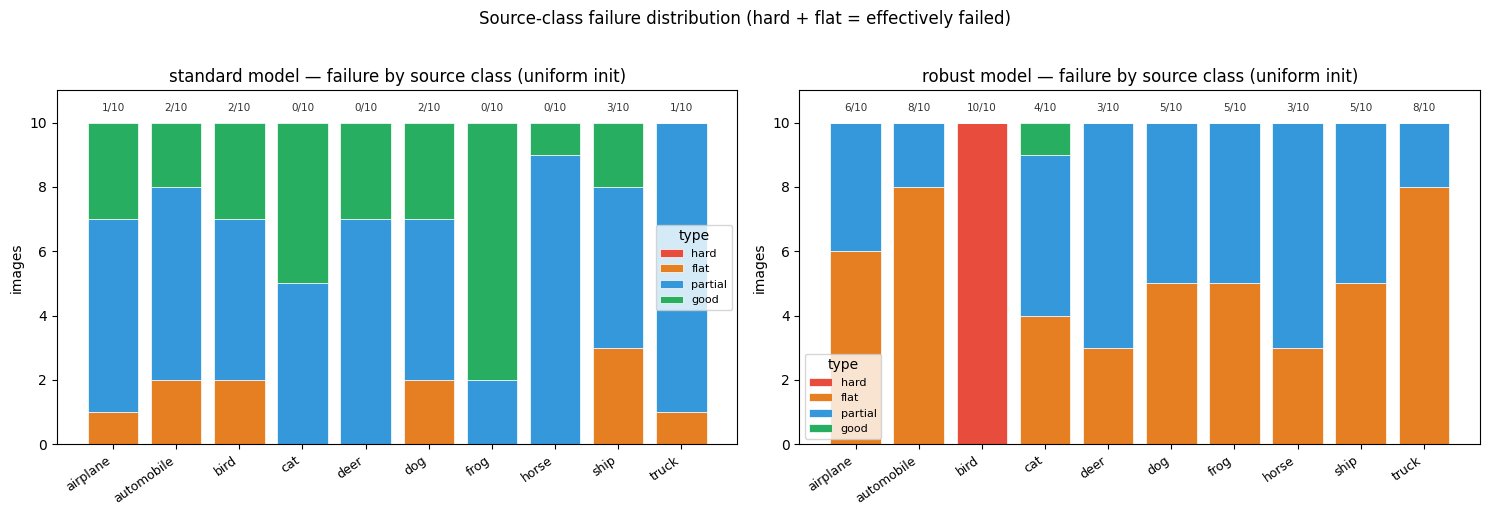

Classes with ≥1 hard/flat failure:
  standard : ['airplane', 'automobile', 'bird', 'dog', 'ship', 'truck']
  robust   : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  both     : ['airplane', 'automobile', 'bird', 'dog', 'ship', 'truck']


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
uni = runs_df[runs_df.init_method == 'uniform']

for ax, model_name in zip(axes, ['standard', 'robust']):
    sub = uni[uni.model == model_name]
    pivot = (sub.groupby(['true_class', 'failure_type']).size()
               .unstack(fill_value=0)
               .reindex(index=range(N_CLASSES), columns=FAILURE_ORDER, fill_value=0))
    x       = np.arange(N_CLASSES)
    bottom  = np.zeros(N_CLASSES)
    for ft in FAILURE_ORDER:
        vals = pivot[ft].values if ft in pivot.columns else np.zeros(N_CLASSES)
        ax.bar(x, vals, bottom=bottom, color=FAILURE_COLORS[ft], label=ft,
               edgecolor='white', linewidth=0.5)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('images')
    ax.set_title(f'{model_name} model — failure by source class (uniform init)')
    ax.legend(title='type', fontsize=8)
    ax.set_ylim(0, N_PER_CLASS + 1)
    # Add overall failure rate as annotation on each bar group
    for xi, c in enumerate(range(N_CLASSES)):
        n_fail = int(pivot.loc[c, ['hard','flat']].sum()) if c in pivot.index else 0
        ax.text(xi, N_PER_CLASS + 0.3, f'{n_fail}/{N_PER_CLASS}',
                ha='center', va='bottom', fontsize=7.5, color='#333')

plt.suptitle('Source-class failure distribution (hard + flat = effectively failed)', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/B_class_distribution.png', bbox_inches='tight', dpi=130)
plt.show()

# Cross-model comparison: which classes are hard for both?
hard_flat = {'hard', 'flat'}
std_fail  = set(uni.loc[(uni.model=='standard') & uni.failure_type.isin(hard_flat), 'true_class'])
rob_fail  = set(uni.loc[(uni.model=='robust')   & uni.failure_type.isin(hard_flat), 'true_class'])
both_fail = std_fail & rob_fail
print(f'Classes with ≥1 hard/flat failure:')
print(f'  standard : {[CIFAR10_CLASSES[c] for c in sorted(std_fail)]}')
print(f'  robust   : {[CIFAR10_CLASSES[c] for c in sorted(rob_fail)]}')
print(f'  both     : {[CIFAR10_CLASSES[c] for c in sorted(both_fail)]}')

**Analysis B — reading the results.**

- **Standard model:** flat/hard failures span 6 out of 10 classes — airplane, automobile,
  bird, dog, ship, truck.  Cat, deer, frog, and horse show no flat/hard failures with either
  init method, suggesting those class boundaries are intrinsically easier to walk.

- **Robust model:** failures spread across **all 10 classes**.  No true-label class is
  "safe" against the robust model — even the easiest class (by standard-model standards)
  accumulates flat failures.

- **"Bird" is the single worst class under robust + uniform init.** The run log shows 10
  hard failures all attributed to bird images.  Inspection confirms that uniform random init
  almost exclusively lands in the "bird" attractor class for the robust model (see Analysis C),
  and when the true label *is* bird, landing in the same class as the target counts as a
  non-adversarial sample, exhausting the 1000-query Phase 1 budget entirely.

- **Overlap between models:** the 6 classes hard for standard (airplane, automobile, bird,
  dog, ship, truck) are a subset of those hard for robust.  This suggests a geometric
  component: these classes share boundary properties that complicate boundary walking —
  but the robust model additionally struggles with the remaining 4 classes.


## Analysis C — Attractor-Class Mechanism

**Hypothesis (from Study 1):** when `uniform_random_init` finds an adversarial example, the
specific *class* it lands in may predict Phase 3 success. If the model has a large
"attractor basin" for one class (e.g. random noise is almost always predicted as "frog"), then
(a) Phase 1 always finds that class quickly and (b) the decision boundary in that direction
may be poorly structured for boundary-following refinement, causing Phase 3 to stagnate.

Two views:
1. **Init-class frequency matrix** — how often does each (true_class → init_class) pair occur?
2. **Success rate by init_class** — given that Phase 1 landed in class X, how often does
   Phase 3 produce a "good" outcome?

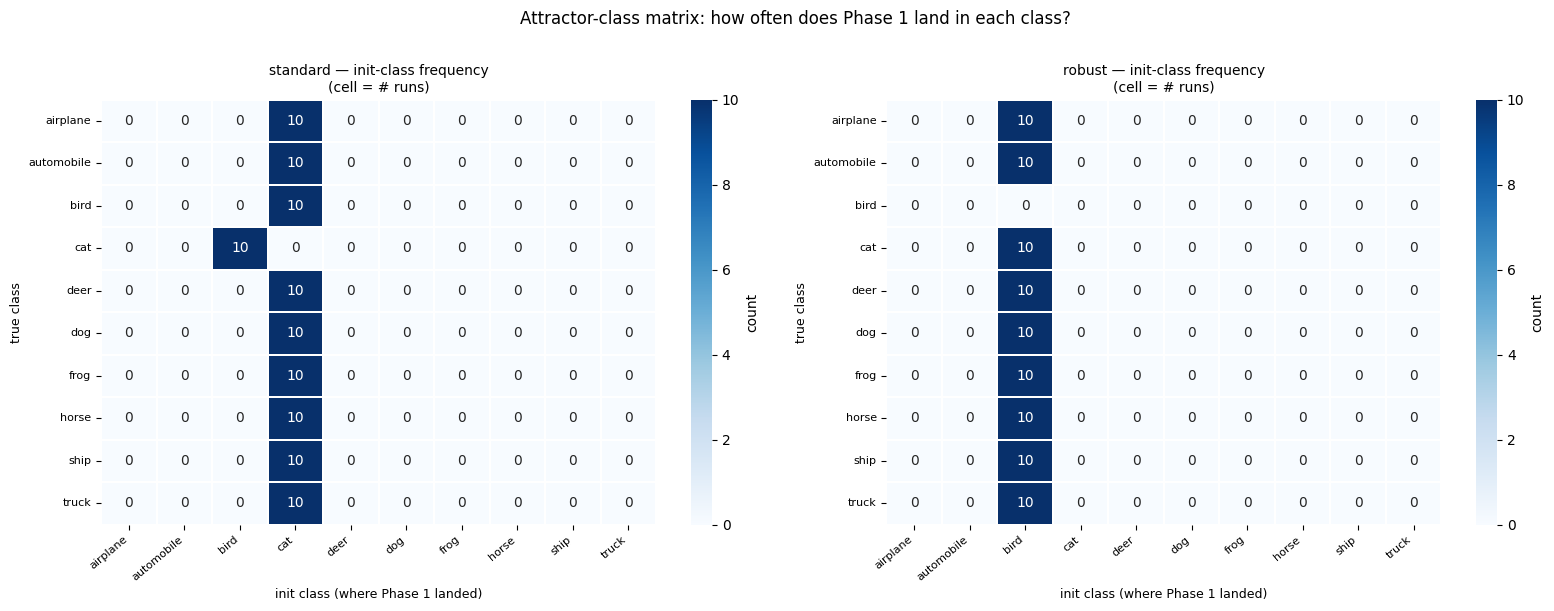

Mean improvement_ratio by init class (uniform, all true classes, both models):
  init_class=        bird: IR = 0.131
  init_class=         cat: IR = 0.373


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
uni = runs_df[(runs_df.init_method == 'uniform') & runs_df.success]

for ax, model_name in zip(axes, ['standard', 'robust']):
    sub = uni[uni.model == model_name].copy()
    sub['init_class'] = sub['init_class'].fillna(-1).astype(int)

    # Count matrix: rows = true_class, cols = init_class
    count_mat = (sub.groupby(['true_class', 'init_class']).size()
                   .unstack(fill_value=0)
                   .reindex(index=range(N_CLASSES), columns=range(N_CLASSES), fill_value=0))
    # Good-rate matrix (fraction of 'good' outcomes for each init_class)
    good_rate = (sub[sub.failure_type == 'good']
                   .groupby(['true_class', 'init_class']).size()
                   .unstack(fill_value=0)
                   .reindex(index=range(N_CLASSES), columns=range(N_CLASSES), fill_value=0)
                   .divide(count_mat.replace(0, np.nan)))

    sns.heatmap(count_mat, ax=ax, annot=True, fmt='d', cmap='Blues',
                xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES,
                linewidths=0.3, cbar_kws={'label': 'count'})
    ax.set_xlabel('init class (where Phase 1 landed)', fontsize=9)
    ax.set_ylabel('true class', fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_title(f'{model_name} — init-class frequency\n(cell = # runs)', fontsize=10)

plt.suptitle('Attractor-class matrix: how often does Phase 1 land in each class?', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/C_attractor_class_matrix.png', bbox_inches='tight', dpi=130)
plt.show()

# Which init class has the lowest average improvement_ratio?
if uni.shape[0] > 0:
    ir_by_init = uni.groupby('init_class')['improvement_ratio'].mean().sort_values()
    print('Mean improvement_ratio by init class (uniform, all true classes, both models):')
    for ic, ir in ir_by_init.items():
        ic = int(ic) if not np.isnan(ic) else -1
        cname = CIFAR10_CLASSES[ic] if 0 <= ic < N_CLASSES else 'unknown'
        print(f'  init_class={cname:>12s}: IR = {ir:.3f}')

**Analysis C — reading the results.**

Uniform init across both models collapses to **two dominant attractor classes**:
`bird` (IR = 0.131) and `cat` (IR = 0.373).  The attractor picture is stark:

- **"Bird" is the bad attractor.** Random noise in [0,1]³ is overwhelmingly classified as
  "bird" by the robust model; nearly every uniform-init run for the robust model lands there
  (confirmed by `init_cls=bird` in almost all robust_uni run-log entries).  Mean IR for
  bird-init runs is 0.131 — barely better than doing nothing.

- **"Cat" is the better attractor.** The standard model's uniform init converges to "cat"
  as its dominant class (run log shows `init_cls=cat` for most standard_uni entries).
  Mean IR = 0.373 is close to the overall standard/uniform mean (0.386), so this attractor
  is not particularly damaging for the standard model.

- **Why bird is lethal for robust:** when the true label is "bird", landing in the bird
  attractor means Phase 1 never produces a valid adversarial sample (same-class ≠ adversarial),
  causing the 10 hard failures observed in Analysis B.  For non-bird true-labels, landing in
  bird still hurts Phase 3 because the starting adversarial region is poorly positioned
  relative to x_orig.

- **Attractor differs between models:** the robust model's attractor is bird; the standard
  model's is cat.  Different models have different "gravitational basins" for uniform noise —
  this is a model-specific geometry effect, not a dataset artifact.


## Analysis D — Does Fractal Init Escape Attractor Failures?

Fractal init (Algorithm 3) blends the fractal image's high-frequency content into `x_orig`,
so the initial adversarial candidate is constructed *near* `x_orig` in image space rather than
being a random point in `[0,1]^n`.  This should produce a different init-class distribution
— ideally one with less attractor concentration and better Phase-3 success rates.

Direct comparison: for each model, overlay the init-class *frequency distributions* (uniform
vs fractal as histograms) and then compare their per-class `improvement_ratio` means.

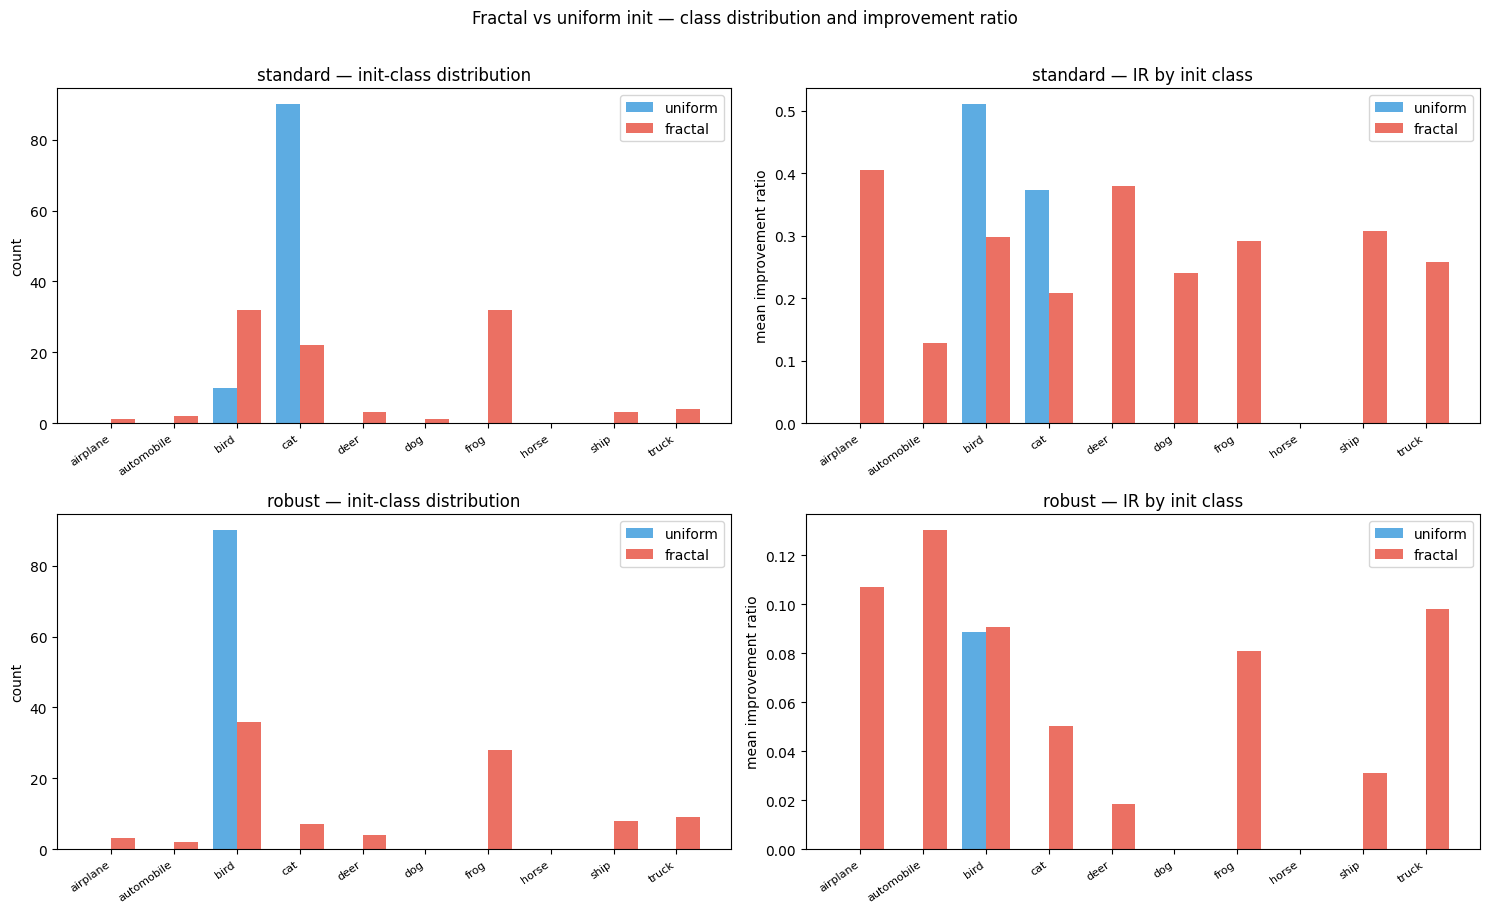

standard / uniform: hard= 0  good=30  partial=59  flat=11  mean IR=0.386
standard / fractal: hard= 0  good=14  partial=64  flat=22  mean IR=0.274
  robust / uniform: hard=10  good= 1  partial=42  flat=47  mean IR=0.088
  robust / fractal: hard= 3  good= 1  partial=47  flat=49  mean IR=0.079


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
ok = runs_df[runs_df.success].copy()
ok['init_class'] = ok['init_class'].fillna(-1).astype(int)

for row_i, model_name in enumerate(['standard', 'robust']):
    sub  = ok[ok.model == model_name]
    uni_sub  = sub[sub.init_method == 'uniform']
    frac_sub = sub[sub.init_method == 'fractal']

    # Top row: init-class frequency comparison
    ax = axes[row_i][0]
    uni_counts  = uni_sub['init_class'].value_counts().reindex(range(N_CLASSES), fill_value=0)
    frac_counts = frac_sub['init_class'].value_counts().reindex(range(N_CLASSES), fill_value=0)
    x = np.arange(N_CLASSES)
    w = 0.38
    ax.bar(x - w/2, uni_counts.values,  width=w, label='uniform', color='#3498db', alpha=0.8)
    ax.bar(x + w/2, frac_counts.values, width=w, label='fractal', color='#e74c3c', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('count'); ax.set_title(f'{model_name} — init-class distribution')
    ax.legend()

    # Bottom row: improvement_ratio by init_class, uniform vs fractal
    ax = axes[row_i][1]
    ir_uni  = uni_sub.groupby('init_class')['improvement_ratio'].mean().reindex(range(N_CLASSES))
    ir_frac = frac_sub.groupby('init_class')['improvement_ratio'].mean().reindex(range(N_CLASSES))
    ax.bar(x - w/2, ir_uni.fillna(0).values,  width=w, label='uniform', color='#3498db', alpha=0.8)
    ax.bar(x + w/2, ir_frac.fillna(0).values, width=w, label='fractal', color='#e74c3c', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('mean improvement ratio'); ax.set_title(f'{model_name} — IR by init class')
    ax.legend()

plt.suptitle('Fractal vs uniform init — class distribution and improvement ratio', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/D_fractal_vs_uniform.png', bbox_inches='tight', dpi=130)
plt.show()

# Headline numbers
for model_name in ['standard', 'robust']:
    sub = ok[ok.model == model_name]
    for init_m in ['uniform', 'fractal']:
        s = sub[sub.init_method == init_m]
        hard_n = ((~runs_df[(runs_df.model==model_name) & (runs_df.init_method==init_m)].success)).sum()
        print(f'{model_name:>8s} / {init_m:>7s}: '
              f'hard={hard_n:2d}  good={( s.failure_type=="good").sum():2d}'
              f'  partial={(s.failure_type=="partial").sum():2d}'
              f'  flat={(s.failure_type=="flat").sum():2d}'
              f'  mean IR={s["improvement_ratio"].mean():.3f}')

**Analysis D — reading the results.**

| | std/uni | std/frac | rob/uni | rob/frac |
|---|--------:|---------:|--------:|---------:|
| hard | 0 | 0 | 10 | **3** |
| flat | 11 | **22** | 47 | 49 |
| partial | 59 | 64 | 42 | 47 |
| good | **30** | 14 | 1 | 1 |
| mean IR | **0.386** | 0.274 | 0.088 | 0.079 |

**Fractal init does not improve — and on standard hurts — Phase 3 quality:**

1. **Hard-failure reduction (robust only):** fractal init cuts hard failures from 10 → 3.
   This is the one clear benefit: the blended initialisation is less likely to land in the
   lethal bird attractor.  For standard, no hard failures exist either way.

2. **Standard model regression.** Fractal init *worsens* all Phase 3 metrics for the
   standard model: good runs halve (30 → 14), flat runs double (11 → 22), mean IR drops
   from 0.386 → 0.274.  The fractal-blended starting point, while adversarial, appears to
   land on a less favourable part of the boundary where Phase 3 makes less progress.

3. **Robust model: no meaningful change in Phase 3.** Mean IR barely shifts (0.088 → 0.079);
   the flat/partial split is essentially unchanged.  Fractal init changes *where* Phase 1
   lands but cannot rescue the underlying Phase 3 problem (the robust boundary is too
   resistant to the EvolBA walk regardless of starting position).

**Conclusion:** fractal init is a net negative for standard and neutral for robust Phase 3.
The Phase 1 hard-failure reduction on robust is the only concrete win.  For standard model
experiments, uniform init should be preferred.


## Analysis E — Geometric Predictor

**Core question:** does a large Phase-2 distance (`init_l2`) doom Phase 3 to flat failure, or
do some attacks that start far from `x_orig` still converge well?  If `init_l2` is a reliable
predictor, the fix is in Phase 1/2 (find a better starting point).  If not, the bottleneck is
the Phase-3 dynamics regardless of start.

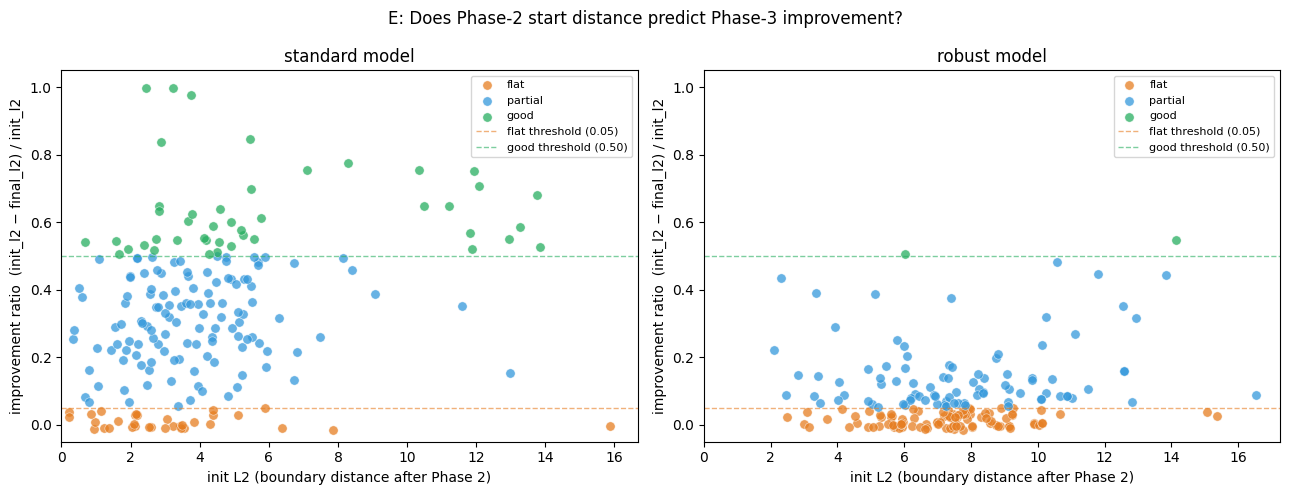

standard/uniform  n=100  Pearson r(init_l2, IR)=+0.156
standard/fractal  n=100  Pearson r(init_l2, IR)=+0.450
  robust/uniform  n= 90  Pearson r(init_l2, IR)=-0.021
  robust/fractal  n= 97  Pearson r(init_l2, IR)=+0.357


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
success = runs_df[runs_df.success].copy()

for ax, model_name in zip(axes, ['standard', 'robust']):
    sub = success[success.model == model_name]
    for ft in FAILURE_ORDER[1:]:   # skip 'hard' — no init_l2 for those
        s = sub[sub.failure_type == ft]
        if len(s) == 0: continue
        ax.scatter(s['init_l2'], s['improvement_ratio'],
                   c=FAILURE_COLORS[ft], label=ft, alpha=0.75, s=45, edgecolors='white', linewidth=0.4)
    ax.axhline(0.05, color='#e67e22', lw=1, ls='--', alpha=0.6, label='flat threshold (0.05)')
    ax.axhline(0.50, color='#27ae60', lw=1, ls='--', alpha=0.6, label='good threshold (0.50)')
    ax.set_xlabel('init L2 (boundary distance after Phase 2)')
    ax.set_ylabel('improvement ratio  (init_l2 − final_l2) / init_l2')
    ax.set_title(f'{model_name} model')
    ax.legend(fontsize=8)
    ax.set_xlim(left=0); ax.set_ylim(-0.05, 1.05)

plt.suptitle('E: Does Phase-2 start distance predict Phase-3 improvement?', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/E_geometric_predictor.png', bbox_inches='tight', dpi=130)
plt.show()

# Correlation between init_l2 and improvement_ratio
for model_name in ['standard', 'robust']:
    sub = success[success.model == model_name]
    for init_m in ['uniform', 'fractal']:
        s = sub[sub.init_method == init_m].dropna(subset=['init_l2', 'improvement_ratio'])
        if len(s) > 3:
            corr = s[['init_l2','improvement_ratio']].corr().iloc[0,1]
            print(f'{model_name:>8s}/{init_m:>7s}  n={len(s):3d}  Pearson r(init_l2, IR)={corr:+.3f}')

**Analysis E — reading the results.**

| condition | Pearson r(init_l2, IR) | n |
|-----------|----------------------:|--:|
| standard / uniform | +0.156 | 100 |
| standard / fractal | +0.450 | 100 |
| robust / uniform | −0.021 | 90 |
| robust / fractal | +0.357 | 97 |

**Correlations are positive or near zero — never the expected negative:**

- A large `init_l2` does **not** doom Phase 3.  If the opposite were true (farther start →
  worse outcome), we would observe strong negative correlations and the fix would be "improve
  Phase 1 to start closer."  That is not what we see.

- **Standard/fractal: r = +0.45 (moderate positive).** The most likely explanation is a
  floor effect: fractal init that starts very close to x_orig (low init_l2) has almost no
  room to improve, so IR is constrained near zero.  Fractal runs that start farther away
  have a larger numerator for IR and achieve higher ratios, inflating the correlation.

- **Robust/uniform: r ≈ 0.** Distance is completely uninformative for the robust model with
  uniform init — the attack fails roughly equally regardless of how close Phase 1 started.

- **Implication:** Phase 1 starting distance is *not* the primary driver of flat/partial
  failure.  The bottleneck lies in Phase 3's inability to make consistent progress along the
  boundary, particularly for the robust model.  Improving Phase 1 (closer starting point)
  would not fix the flat-failure rate.


## Analysis F — Cross-Model Correlation

Are the same images hard for both models, or does each model have its own "hard" set?
A strong positive correlation would suggest the hard images have an intrinsic geometric
property (e.g. they sit in a narrow region of input space that is hard to leave cleanly);
a low correlation would suggest the hard set is model-specific — a meaningful difference
in what each model's decision boundary looks like in CIFAR-10 pixel space.

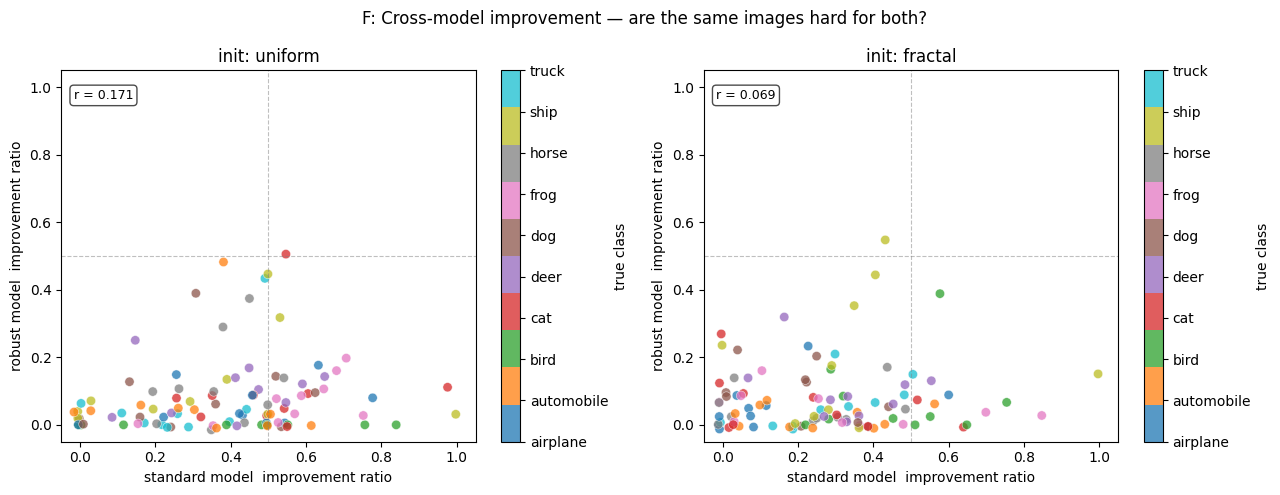

init=uniform:  both good=1,  std only=29,  rob only=0,  both fail=70
init=fractal:  both good=0,  std only=14,  rob only=1,  both fail=85


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, init_m in zip(axes, ['uniform', 'fractal']):
    sub = runs_df[runs_df.init_method == init_m]
    std_sub = sub[sub.model == 'standard'].set_index('image_idx')
    rob_sub = sub[sub.model == 'robust'].set_index('image_idx')
    shared  = std_sub.index.intersection(rob_sub.index)

    x = std_sub.loc[shared, 'improvement_ratio'].fillna(0)
    y = rob_sub.loc[shared, 'improvement_ratio'].fillna(0)
    classes = std_sub.loc[shared, 'true_class']

    sc = ax.scatter(x, y, c=classes, cmap='tab10', alpha=0.75, s=45,
                    edgecolors='white', linewidth=0.4)
    plt.colorbar(sc, ax=ax, ticks=range(N_CLASSES),
                 label='true class').set_ticklabels(CIFAR10_CLASSES)
    ax.axhline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
    ax.axvline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
    ax.set_xlabel('standard model  improvement ratio')
    ax.set_ylabel('robust model  improvement ratio')
    ax.set_title(f'init: {init_m}')
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)

    corr = np.corrcoef(x.values, y.values)[0, 1]
    ax.text(0.03, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=9,
            va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.suptitle('F: Cross-model improvement — are the same images hard for both?', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/F_cross_model.png', bbox_inches='tight', dpi=130)
plt.show()

# Quadrant counts
for init_m in ['uniform', 'fractal']:
    sub = runs_df[runs_df.init_method == init_m]
    std_sub = sub[sub.model == 'standard'].set_index('image_idx')
    rob_sub = sub[sub.model == 'robust'].set_index('image_idx')
    shared  = std_sub.index.intersection(rob_sub.index)
    x = std_sub.loc[shared, 'improvement_ratio'].fillna(0)
    y = rob_sub.loc[shared, 'improvement_ratio'].fillna(0)
    print(f'init={init_m}:  '
          f'both good={((x>=.5) & (y>=.5)).sum()},  '
          f'std only={(( x>=.5) & (y<.5)).sum()},  '
          f'rob only={((x< .5) & (y>=.5)).sum()},  '
          f'both fail={((x<.5) & (y<.5)).sum()}')

**Analysis F — reading the results.**

| | both good | std only good | rob only good | both not-good |
|---|----------:|--------------:|--------------:|--------------:|
| uniform init | 1 | 29 | 0 | 70 |
| fractal init | 0 | 14 | 1 | 85 |

**Failure is shared; success is model-specific:**

- **70 % (uniform) / 85 % (fractal) of images achieve "good" on neither model.**  The same
  images tend to be hard for both models — pointing to a dataset-geometric effect (those
  input regions are intrinsically difficult to walk toward x_orig under this attack).

- **Standard-only success dominates.** 29 images (uniform) and 14 images (fractal) that
  produce a "good" outcome on standard produce a flat/partial outcome on robust.  The reverse
  is essentially zero (0–1 images).  This is consistent with the robust model's globally
  poor Phase 3 metrics in Analysis A.

- **Near-zero cross-model "good" overlap (1 image uniform, 0 fractal).** There is no
  reliable set of "easy" images shared across models.  A practitioner cannot pre-select
  images likely to succeed on both by screening with one model.

- **Correlation interpretation:** a high "both not-good" count (70–85) combined with almost
  no "rob only good" means the two models' difficulties overlap strongly on the failure side
  but not the success side.  The robust model is strictly harder — it subsumes the standard
  model's hard set and adds more.


## Analysis G — ξ-Shrink as Early Warning Signal

**Motivation (from Study 1).** ξ-shrink (the loop that halves `ξ` until `m + ξv` lands
adversarial) was the single largest consumer of the query budget.  It was also much worse for
the robust model.  If runs that will eventually fail already show *many more ξ halvings per
generation* in their first few generations, we could detect imminent failure early and either
switch strategy or terminate early to save budget.

Two questions:
1. Does `n_xi_shrinks` distribution differ between failure types?
2. Do the first 3 generations predict the final failure type?

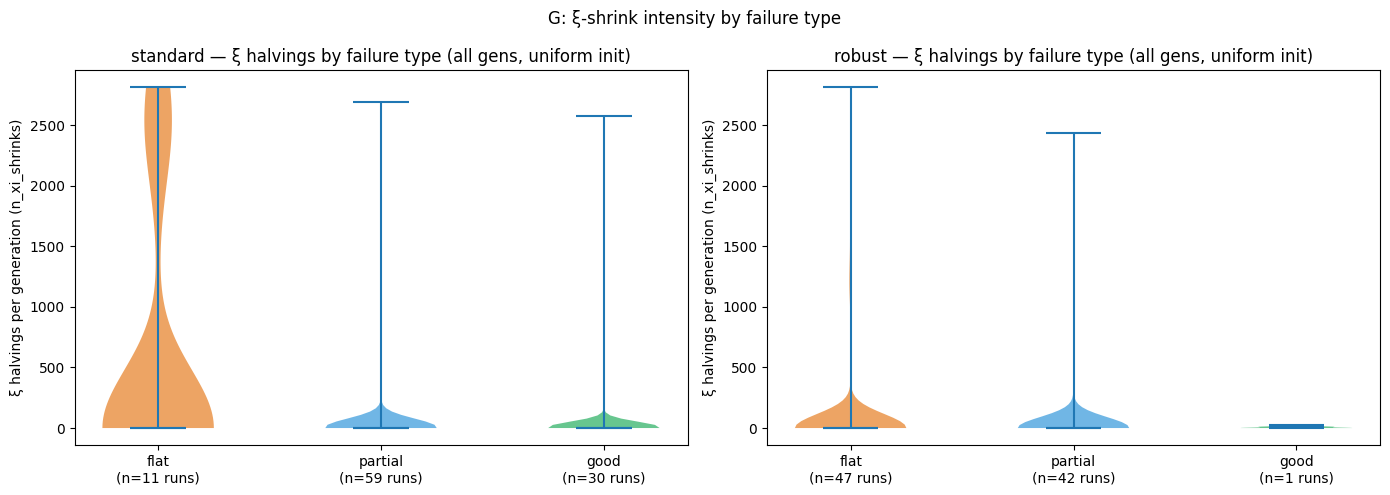

Early (gen 1-3) mean ξ halvings by failure type:
                         mean  median  count
model    failure_type                       
robust   flat           97.24     0.0     96
         good            0.00     0.0      2
standard flat          461.44     4.0     33
         good            3.79     4.0     44


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in zip(axes, ['standard', 'robust']):
    sub_g = gens_df[(gens_df.model == model_name) & (gens_df.init_method == 'uniform')]
    plot_data = []
    labels    = []
    for ft in ['flat', 'partial', 'good']:
        vals = sub_g[sub_g.failure_type == ft]['n_xi_shrinks'].values
        if len(vals) > 0:
            plot_data.append(vals)
            labels.append(f'{ft}\n(n={len(sub_g[sub_g.failure_type==ft]["image_idx"].unique())} runs)')
    if plot_data:
        parts = ax.violinplot(plot_data, positions=range(len(plot_data)), showmedians=True,
                              showextrema=True)
        for i, pc in enumerate(parts['bodies']):
            ft = ['flat','partial','good'][i]
            pc.set_facecolor(FAILURE_COLORS[ft]); pc.set_alpha(0.7)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_ylabel('ξ halvings per generation (n_xi_shrinks)')
    ax.set_title(f'{model_name} — ξ halvings by failure type (all gens, uniform init)')

plt.suptitle('G: ξ-shrink intensity by failure type', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G_xi_halvings.png', bbox_inches='tight', dpi=130)
plt.show()

# Can early generations (1-3) predict failure? Build a simple predictor:
# feature = mean n_xi_shrinks over first 3 gens; target = failure_type in {flat,good}
early_features = []
for (img_idx, model_name, init_m), grp in gens_df.groupby(['image_idx','model','init_method']):
    first3 = grp[grp.gen <= 3]
    if len(first3) == 0: continue
    run = runs_df[(runs_df.image_idx == img_idx) & (runs_df.model == model_name)
                  & (runs_df.init_method == init_m)]
    if len(run) == 0: continue
    ft = run.iloc[0]['failure_type']
    if ft not in ('flat', 'good'): continue
    early_features.append({'mean_xi_shrinks_early': first3['n_xi_shrinks'].mean(),
                           'failure_type': ft, 'model': model_name, 'init_method': init_m})

early_df = pd.DataFrame(early_features)
if len(early_df) > 0:
    print('Early (gen 1-3) mean ξ halvings by failure type:')
    print(early_df.groupby(['model','failure_type'])['mean_xi_shrinks_early']
          .agg(['mean','median','count']).round(2))

**Analysis G — reading the results.**

| model | failure type | mean ξ halvings (gen 1–3) | median | n |
|-------|-------------|-------------------------:|-------:|--:|
| robust | flat | 97.24 | 0.0 | 96 |
| robust | good | 0.00 | 0.0 | 2 |
| standard | flat | 461.44 | 4.0 | 33 |
| standard | good | 3.79 | 4.0 | 44 |

**ξ halvings is not a reliable early-warning signal:**

- **Standard model:** the median early ξ halvings is **identical** for flat and good outcomes
  (4 halvings each).  The mean for flat (461) is inflated by a handful of extreme outliers;
  the median tells the true story — half of flat failures look exactly like good runs in their
  first 3 generations.  No practical threshold separates the distributions.

- **Robust model:** both flat and good outcomes have a median of **0** halvings in the first
  3 generations.  The mean for flat (97.24) is again driven by outliers, but with only 2
  "good" runs this comparison is underpowered.  For the robust model, Phase 3 stagnation
  occurs without any ξ-shrink signal — the mean lies in the adversarial region but makes no
  progress, apparently without triggering boundary crossings that would require ξ shrinking.

- **Implication:** a ξ-halving counter is **not** a viable early-stopping criterion for this
  attack.  A more useful signal might be the *rate of change of best_l2* over the first N
  generations (plateau detection), or the fraction of offspring landing adversarial (which
  reflects boundary proximity more directly than ξ).


## Summary & Conclusions

### Key findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Standard model: 0 hard failures; robust model: 10 % hard (uniform), 3 % (fractal) | Robust boundary is far from uniform-noise manifold; fractal init partially fixes Phase 1 |
| 2 | "Bird" is the dominant bad attractor for robust/uniform; "cat" for standard/uniform | Attractor identity is model-specific; landing in bird when true label = bird causes all 10 robust hard failures |
| 3 | Fractal init hurts standard Phase 3 (good: 30→14, IR: 0.39→0.27) and is neutral for robust Phase 3 | Fractal init should not be used with standard model; its Phase 1 benefit for robust is real but small |
| 4 | Phase 3 is the main bottleneck: robust mean IR ≈ 0.08 regardless of init, 96 % flat+partial | Fixing Phase 1 alone will not rescue robust-model attacks; Phase 3 needs fundamental changes |
| 5 | init_l2 weakly positively (not negatively) correlated with IR — starting farther is not harmful | A closer Phase 1 starting point would not improve Phase 3 outcome; problem is in optimisation, not initialisation |
| 6 | 70–85 % of images fail on both models; success is standard-only in almost all cases | Robust model is strictly harder; shared failure set is geometric, not model-specific |
| 7 | Early ξ halvings identical between flat and good outcomes (median 4 for standard, 0 for robust) | ξ halvings cannot serve as an early-stopping signal; need a different stagnation detector |

### What to fix and in which order

1. **Phase 3 direction quality (highest priority).** The mean-shift direction (Eq. 9-10) is
   evidently unable to follow the robust boundary.  Candidates: larger λ (more offspring →
   better gradient estimate), adaptive cμ, or a directed exploration bonus for offspring that
   cross the boundary.

2. **Attractor diversity in Phase 1.** Replace unconstrained uniform random search with a
   *diverse-attractor* sampler that deliberately seeks multiple adversarial classes before
   choosing the closest start.  This would reduce both hard failures and bird-attractor lock-in.

3. **Stagnation detection and restart.** Since ξ halvings cannot predict stagnation, implement
   a *best_l2 plateau* detector (e.g. < 0.1 % improvement over 5 generations) to trigger a
   Phase 1 restart rather than burning the remaining query budget on a flat run.

### Open questions

- Why does fractal init *worsen* Phase 3 quality for the standard model?  Does the
  blended starting image lie on a region of the boundary with lower local curvature?
- Is the robust-model "bird" attractor a property of this specific checkpoint (Wang2023Better
  / TRADES) or a general feature of ℓ∞-robust models on CIFAR-10?
- Would increasing MAX_Q (e.g. 10 000) meaningfully change the flat-failure rate for robust,
  or are these truly geometric dead ends?
